In [ ]:
import pandas as pd
df = pd.read_csv('bank.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [ ]:
# Répartition de la variable cible
counts = df["deposit"].value_counts()
percentages = (df["deposit"].value_counts(normalize=True) * 100).round(2)


print(f"deposit = no  : {counts['no']} lignes, soit {percentages['no']} %")
print(f"deposit = yes : {counts['yes']} lignes, soit {percentages['yes']} %")

# Sa répartition montre une légère majorité de non-souscripteurs (52,62 %) contre 47,38 % de souscripteurs,
# ce qui traduit un jeu de données relativement équilibré.


deposit = no  : 5873 lignes, soit 52.62 %
deposit = yes : 5289 lignes, soit 47.38 %


In [ ]:
# Séparer les colonnes numériques et catégorielles
colonne_num = df.select_dtypes(include= ["int64", "float64"]).columns.tolist()
colonne_cat = df.select_dtypes(include = ["object"]).columns.tolist()
print("Colonnes numériques :", colonne_num)
print("Colonnes catégorielles :", colonne_cat)


Colonnes numériques : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Colonnes catégorielles : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [ ]:
# 1) Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

# 2) Doublons
print("\nNombre de doublons exacts :")
print(df.duplicated().sum())

# 3) Modalités 'unknown' dans les colonnes qualitatives
cols_cat = df.select_dtypes(include="object").columns

print("\nNombre de 'unknown' par variable qualitative :")
for col in cols_cat:
    nb_unknown = (df[col] == "unknown").sum()
    if nb_unknown > 0:
        print(f"{col} : {nb_unknown}")

Valeurs manquantes par colonne :
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Nombre de doublons exacts :
0

Nombre de 'unknown' par variable qualitative :
job : 70
education : 497
contact : 2346
poutcome : 8326


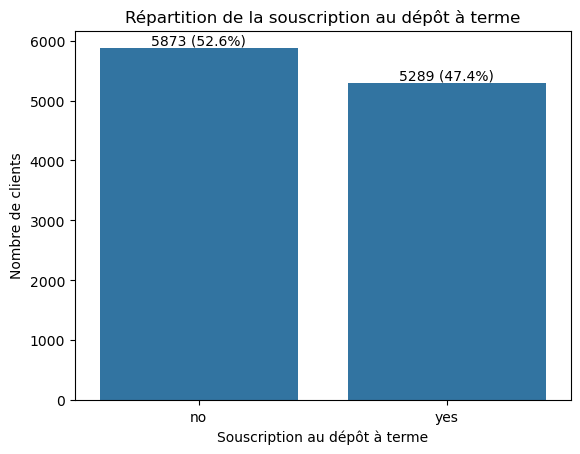

In [ ]:
# Répartition de la variable cible
import seaborn as sns
import matplotlib.pyplot as plt
counts = df['deposit'].value_counts()

sns.countplot(x='deposit', data=df, order=counts.index)
plt.title("Répartition de la souscription au dépôt à terme")
plt.xlabel("Souscription au dépôt à terme")
plt.ylabel("Nombre de clients")

for i, count in enumerate(counts):
    plt.text(i, count + 50, f"{count} ({count/len(df)*100:.1f}%)", ha='center')

plt.show()
# la campagne n’est pas face à un échec total, puisque près de la moitié des clients ont souscrit,
# mais la légère domination des non-souscripteurs laisse penser qu’il existe des leviers d’optimisation du ciblage ou du mode de contact.

count    11162.000000
mean        41.231948
std         11.913369
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64


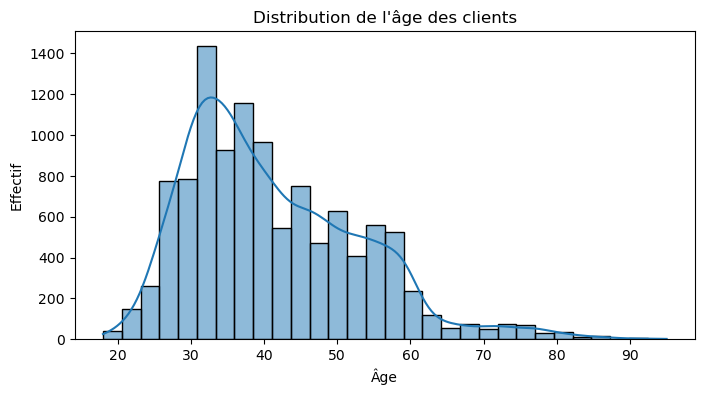

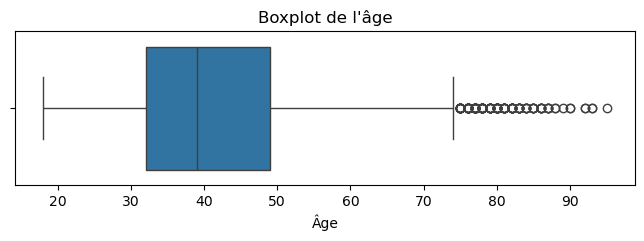

In [ ]:
# Analyse univariée d’une variable numérique "age"

import matplotlib.pyplot as plt
import seaborn as sns

# Statistiques descriptives de age
print(df["age"].describe())

# Histogramme
plt.figure(figsize=(8,4))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribution de l'âge des clients")
plt.xlabel("Âge")
plt.ylabel("Effectif")
plt.show()

# Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df["age"])
plt.title("Boxplot de l'âge")
plt.xlabel("Âge")
plt.show()

count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64


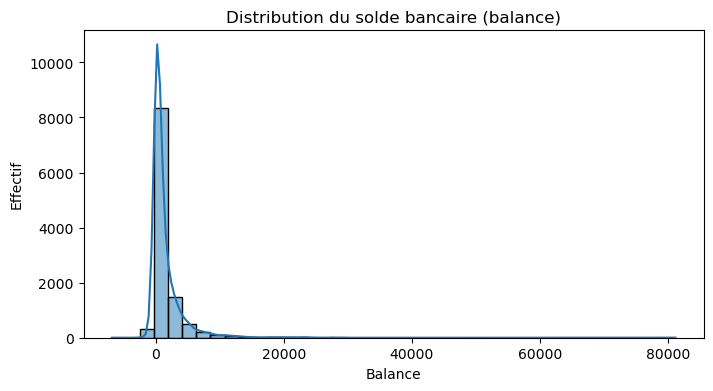

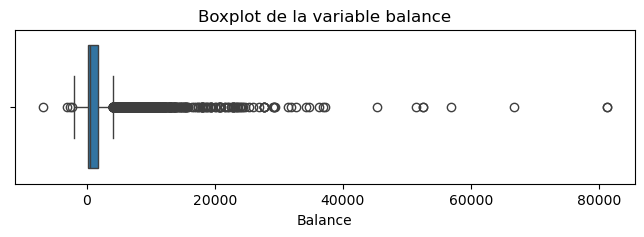

In [ ]:
# Analyse univariée d’une variable numérique "balance"

print(df["balance"].describe())

plt.figure(figsize=(8,4))
sns.histplot(df["balance"], bins=40, kde=True)
plt.title("Distribution du solde bancaire (balance)")
plt.xlabel("Balance")
plt.ylabel("Effectif")
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=df["balance"])
plt.title("Boxplot de la variable balance")
plt.xlabel("Balance")
plt.show()

count    11162.000000
mean       371.993818
std        347.128386
min          2.000000
25%        138.000000
50%        255.000000
75%        496.000000
max       3881.000000
Name: duration, dtype: float64


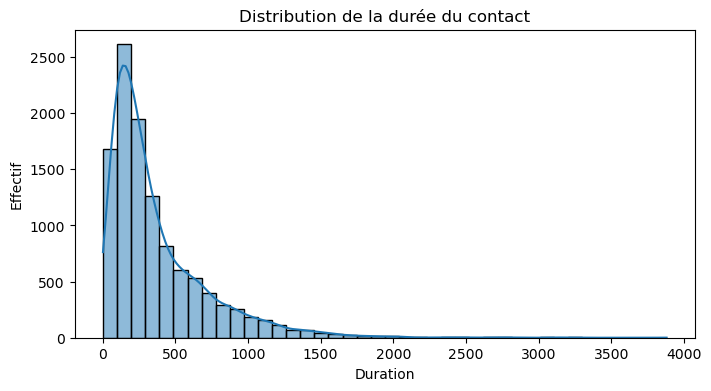

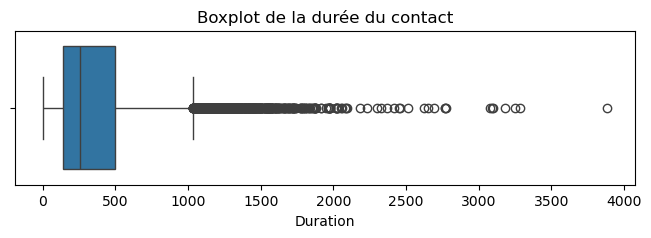

In [ ]:
# Analyse univariée de duration

print(df["duration"].describe())

plt.figure(figsize=(8,4))
sns.histplot(df["duration"], bins=40, kde=True)
plt.title("Distribution de la durée du contact")
plt.xlabel("Duration")
plt.ylabel("Effectif")
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=df["duration"])
plt.title("Boxplot de la durée du contact")
plt.xlabel("Duration")
plt.show()

count    11162.000000
mean         2.508421
std          2.722077
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64


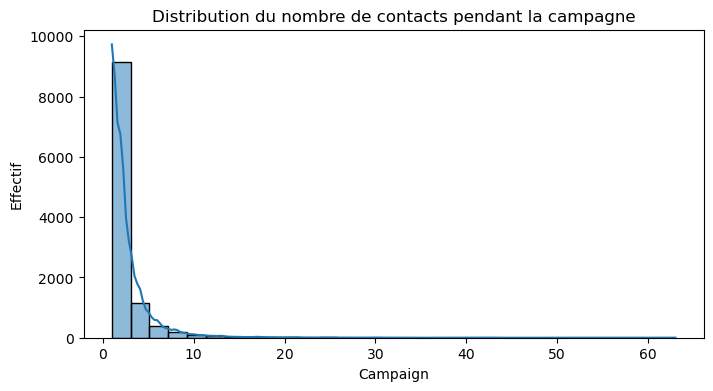

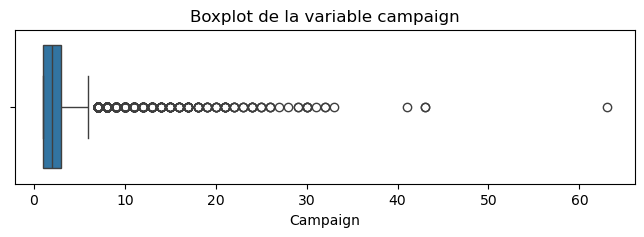

In [ ]:
# Analyse univariée de campaign

print(df["campaign"].describe())

plt.figure(figsize=(8,4))
sns.histplot(df["campaign"], bins=30, kde=True)
plt.title("Distribution du nombre de contacts pendant la campagne")
plt.xlabel("Campaign")
plt.ylabel("Effectif")
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=df["campaign"])
plt.title("Boxplot de la variable campaign")
plt.xlabel("Campaign")
plt.show()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64


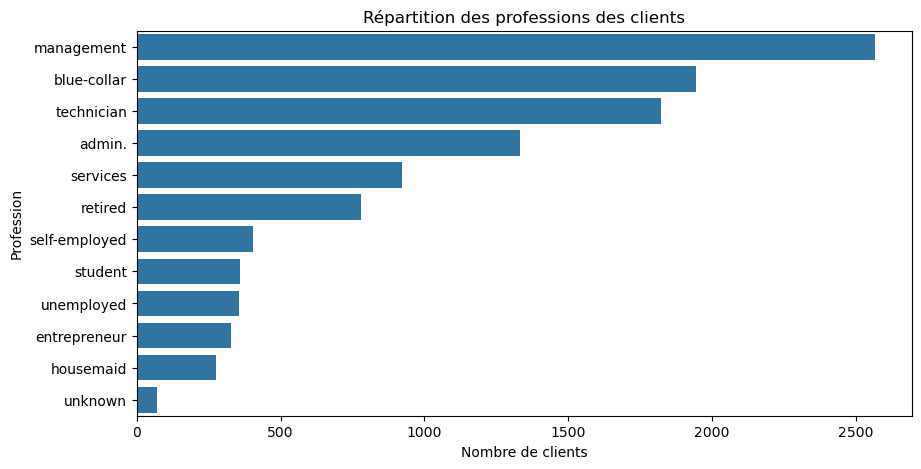

In [ ]:
# Analyse univariée job

print(df["job"].value_counts())

plt.figure(figsize=(10,5))
sns.countplot(y="job", data=df, order=df["job"].value_counts().index)
plt.title("Répartition des professions des clients")
plt.xlabel("Nombre de clients")
plt.ylabel("Profession")
plt.show()

contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64


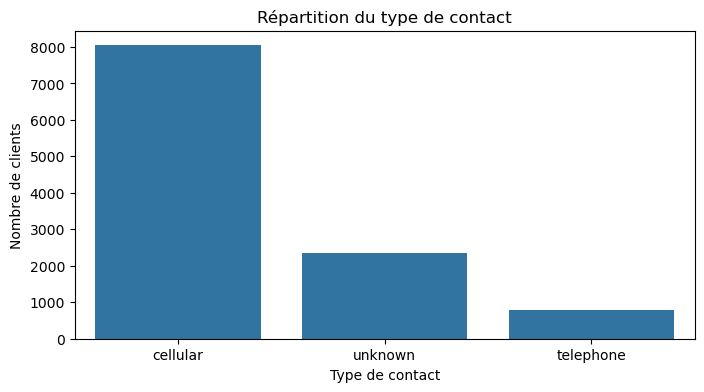

In [ ]:
# Analyse univariée contact

print(df["contact"].value_counts())

plt.figure(figsize=(8,4))
sns.countplot(x="contact", data=df, order=df["contact"].value_counts().index)
plt.title("Répartition du type de contact")
plt.xlabel("Type de contact")
plt.ylabel("Nombre de clients")
plt.show()

poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64


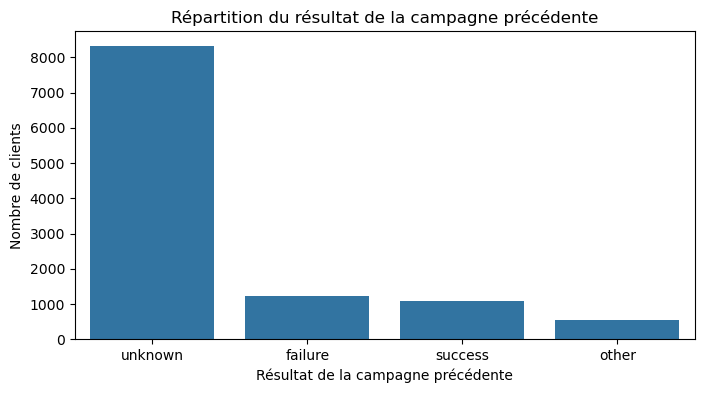

In [ ]:
# Analyse univariée poutcome

print(df["poutcome"].value_counts())

plt.figure(figsize=(8,4))
sns.countplot(x="poutcome", data=df, order=df["poutcome"].value_counts().index)
plt.title("Répartition du résultat de la campagne précédente")
plt.xlabel("Résultat de la campagne précédente")
plt.ylabel("Nombre de clients")
plt.show()
# La majorité des clients ont un résultat précédent unknown, ce qui limite un peu l’interprétation de la variable.
# Parmi les cas connus, les catégories failure et success sont les plus fréquentes.

          count       mean        std   min   25%   50%   75%   max
deposit                                                            
no       5873.0  40.837391  10.264815  18.0  33.0  39.0  48.0  89.0
yes      5289.0  41.670070  13.497781  18.0  31.0  38.0  50.0  95.0


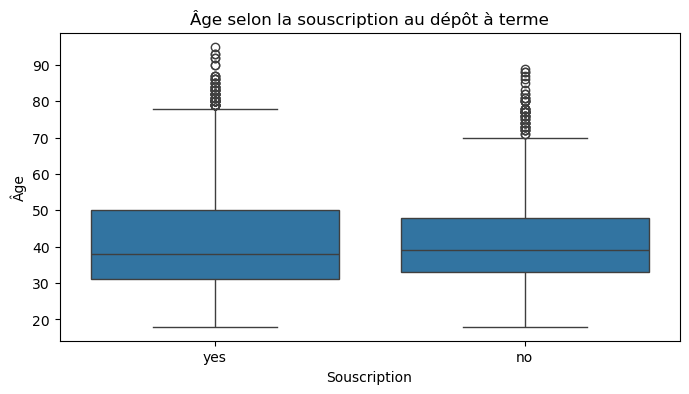

In [ ]:
# Analyse bivariée age vs deposit

# Statistiques descriptives de l'âge selon la cible
print(df.groupby("deposit")["age"].describe())

# Boxplot de l'âge selon la souscription
plt.figure(figsize=(8,4))
sns.boxplot(x="deposit", y="age", data=df)
plt.title("Âge selon la souscription au dépôt à terme")
plt.xlabel("Souscription")
plt.ylabel("Âge")
plt.show()
# Les distributions d’âge des deux groupes sont très similaires.
# Les souscripteurs sont légèrement plus âgés en moyenne, mais la différence semble faible.

          count         mean          std     min    25%    50%     75%  \
deposit                                                                   
no       5873.0  1280.227141  2933.411934 -6847.0   64.0  414.0  1324.0   
yes      5289.0  1804.267915  3501.104777 -3058.0  210.0  733.0  2159.0   

             max  
deposit           
no       66653.0  
yes      81204.0  


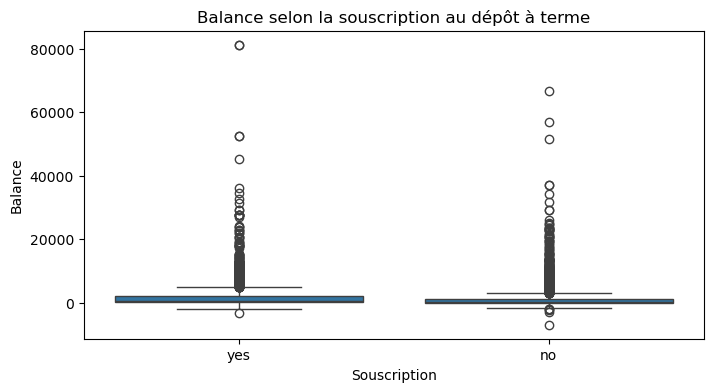

In [ ]:
# Balance vs deposit

print(df.groupby("deposit")["balance"].describe())

plt.figure(figsize=(8,4))
sns.boxplot(x="deposit", y="balance", data=df)
plt.title("Balance selon la souscription au dépôt à terme")
plt.xlabel("Souscription")
plt.ylabel("Balance")
plt.show()
# Les clients qui souscrivent ont en général un solde bancaire plus élevé.
# Mais la variable est très dispersée et contient beaucoup de valeurs extrêmes.

          count        mean         std  min    25%    50%    75%     max
deposit                                                                  
no       5873.0  223.130257  208.577530  2.0   94.0  163.0  282.0  3284.0
yes      5289.0  537.294574  392.525262  8.0  244.0  426.0  725.0  3881.0


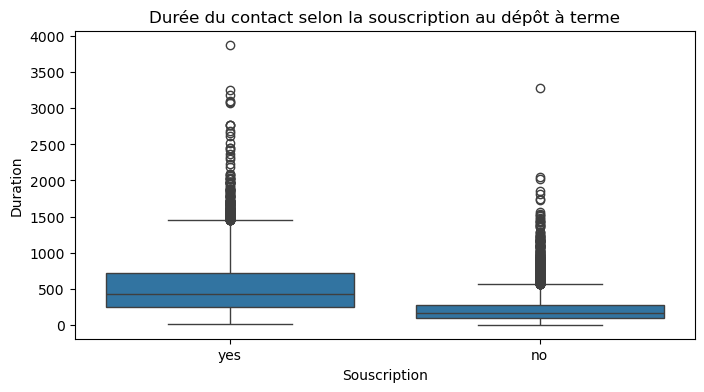

In [ ]:
# duration vs deposit

print(df.groupby("deposit")["duration"].describe())

plt.figure(figsize=(8,4))
sns.boxplot(x="deposit", y="duration", data=df)
plt.title("Durée du contact selon la souscription au dépôt à terme")
plt.xlabel("Souscription")
plt.ylabel("Duration")
plt.show()
# Les clients qui souscrivent ont en général des appels beaucoup plus longs.
# La durée du contact semble donc être une variable très liée à la souscription.

          count      mean       std  min  25%  50%  75%   max
deposit                                                      
no       5873.0  2.839264  3.244474  1.0  1.0  2.0  3.0  63.0
yes      5289.0  2.141047  1.921826  1.0  1.0  2.0  3.0  32.0


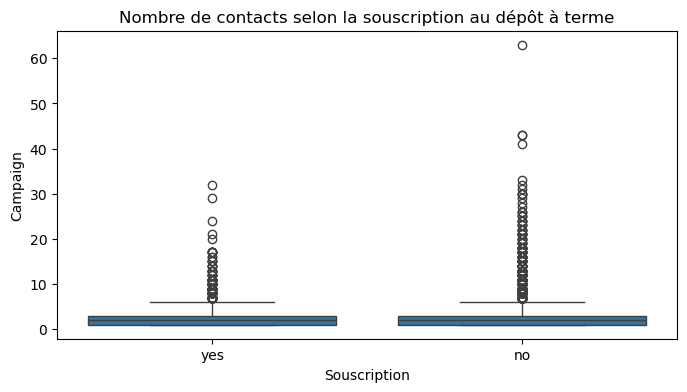

In [ ]:
# campaign vs deposit

print(df.groupby("deposit")["campaign"].describe())

plt.figure(figsize=(8,4))
sns.boxplot(x="deposit", y="campaign", data=df)
plt.title("Nombre de contacts selon la souscription au dépôt à terme")
plt.xlabel("Souscription")
plt.ylabel("Campaign")
plt.show()
# Les non-souscripteurs ont été légèrement plus contactés que les souscripteurs.
# Cela peut indiquer qu’un grand nombre de relances n’est pas nécessairement efficace.

Effectifs :
deposit          no   yes
job                      
admin.          703   631
blue-collar    1236   708
entrepreneur    205   123
housemaid       165   109
management     1265  1301
retired         262   516
self-employed   218   187
services        554   369
student          91   269
technician      983   840
unemployed      155   202
unknown          36    34

Taux de souscription (%) :
deposit           no    yes
job                        
admin.         52.70  47.30
blue-collar    63.58  36.42
entrepreneur   62.50  37.50
housemaid      60.22  39.78
management     49.30  50.70
retired        33.68  66.32
self-employed  53.83  46.17
services       60.02  39.98
student        25.28  74.72
technician     53.92  46.08
unemployed     43.42  56.58
unknown        51.43  48.57


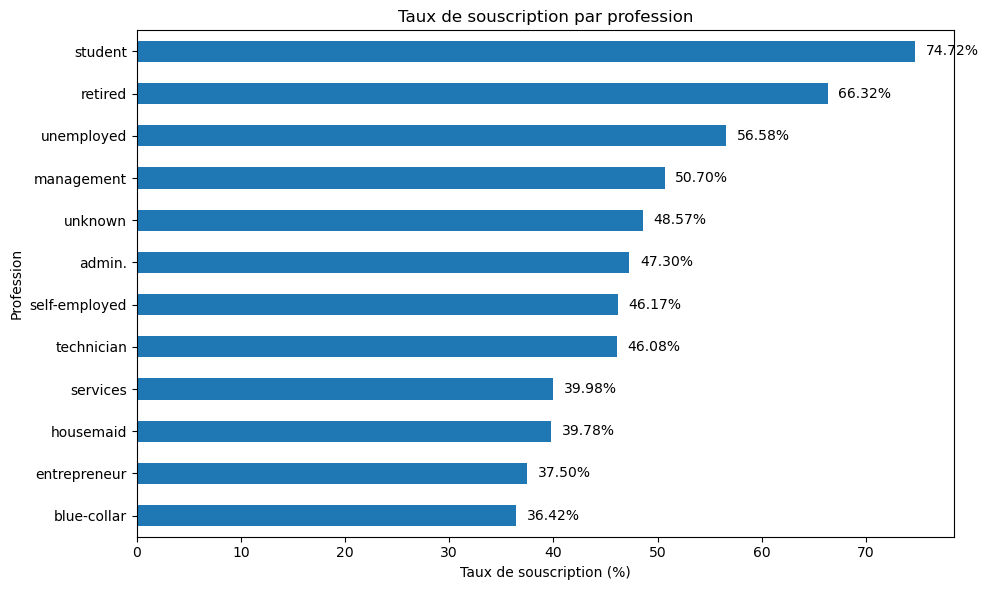

In [ ]:
# job vs deposit

# Tableau croisé en effectifs
ct_job = pd.crosstab(df["job"], df["deposit"])
print("Effectifs :")
print(ct_job)

# Taux de souscription par profession
job_rate = pd.crosstab(df["job"], df["deposit"], normalize="index") * 100
print("\nTaux de souscription (%) :")
print(job_rate.round(2))

rates = job_rate["yes"].sort_values()
rates.plot(kind='barh', figsize=(10,6))

for i, v in enumerate(rates):
    plt.text(v + 1, i, f"{v:.2f}%", va="center")

plt.title("Taux de souscription par profession")
plt.xlabel("Taux de souscription (%)")
plt.ylabel("Profession")
plt.tight_layout()
plt.show()
# Les students et les retired ont les taux de souscription les plus élevés, tandis que les blue-collar et les entrepreneurs ont les plus faibles.
# La profession semble donc influencer la probabilité de souscrire au dépôt à terme.


Effectifs :
deposit      no   yes
contact              
cellular   3673  4369
telephone   384   390
unknown    1816   530

Taux de souscription (%) :
deposit       no    yes
contact                
cellular   45.67  54.33
telephone  49.61  50.39
unknown    77.41  22.59


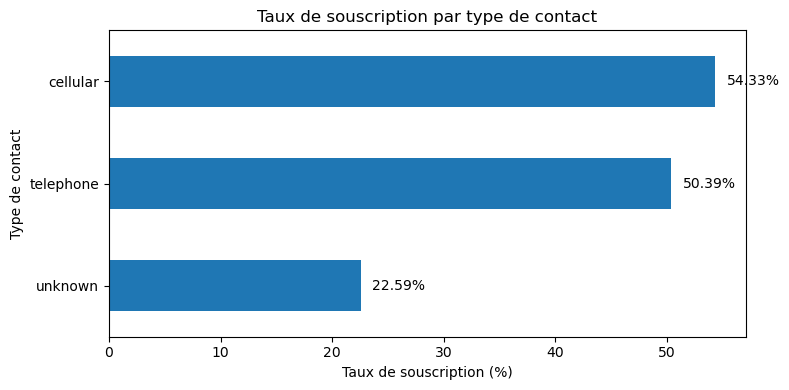

In [ ]:
# contact vs deposit

# Effectifs
ct_contact = pd.crosstab(df["contact"], df["deposit"])
print("Effectifs :")
print(ct_contact)

# Taux de souscription
contact_rate = pd.crosstab(df["contact"], df["deposit"], normalize="index") * 100
print("\nTaux de souscription (%) :")
print(contact_rate.round(2))
contact_rate = pd.crosstab(df['contact'], df['deposit'], normalize='index') * 100
rates = contact_rate["yes"].sort_values()

rates.plot(kind='barh', figsize=(8,4))

for i, v in enumerate(rates):
    plt.text(v + 1, i, f"{v:.2f}%", va="center")

plt.title("Taux de souscription par type de contact")
plt.xlabel("Taux de souscription (%)")
plt.ylabel("Type de contact")
plt.tight_layout()
plt.show()
# Les clients contactés par cellular et telephone souscrivent plus souvent que ceux pour lesquels le type de contact est unknown.
# Le canal cellular semble être le plus favorable à la souscription.

Effectifs :
deposit     no   yes
poutcome            
failure    610   618
other      230   307
success     93   978
unknown   4940  3386

Taux de souscription (%) :
deposit      no    yes
poutcome              
failure   49.67  50.33
other     42.83  57.17
success    8.68  91.32
unknown   59.33  40.67


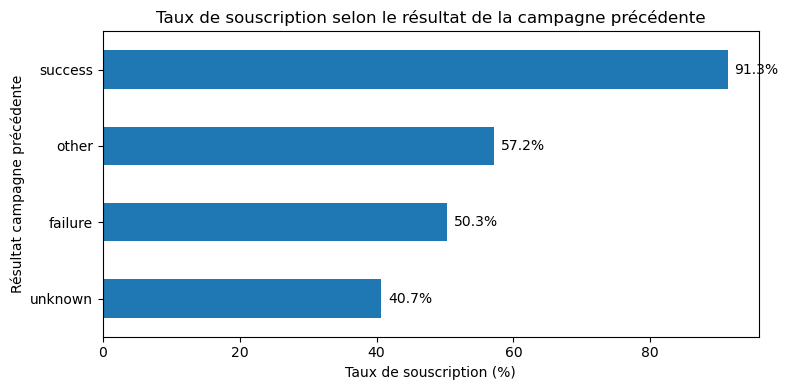

In [ ]:
# poutcome vs deposit

poutcome_rate = pd.crosstab(df['poutcome'], df['deposit'], normalize='index') * 100
rates = poutcome_rate["yes"].sort_values()

print("Effectifs :")
print(pd.crosstab(df['poutcome'], df['deposit']))

print("\nTaux de souscription (%) :")
print(poutcome_rate.round(2))

rates.plot(kind='barh', figsize=(8,4))

for i, v in enumerate(rates):
    plt.text(v + 1, i, f"{v:.1f}%", va="center")

plt.title("Taux de souscription selon le résultat de la campagne précédente")
plt.xlabel("Taux de souscription (%)")
plt.ylabel("Résultat campagne précédente")
plt.tight_layout()
plt.show()
# Le résultat de la campagne précédente est une variable très discriminante.
# Les clients ayant déjà eu un success auparavant souscrivent très souvent de nouveau, contrairement aux clients avec un historique unknown.

Effectifs :
deposit    no   yes
housing            
no       2527  3354
yes      3346  1935

Taux de souscription (%) :
deposit     no    yes
housing              
no       42.97  57.03
yes      63.36  36.64


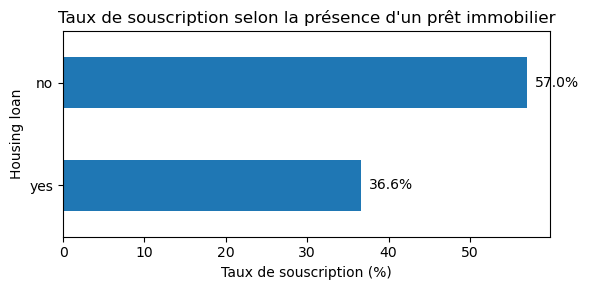

In [ ]:
# housing vs deposit
housing_rate = pd.crosstab(df['housing'], df['deposit'], normalize='index') * 100
rates = housing_rate["yes"].sort_values()

print("Effectifs :")
print(pd.crosstab(df['housing'], df['deposit']))

print("\nTaux de souscription (%) :")
print(housing_rate.round(2))

rates.plot(kind='barh', figsize=(6,3))

for i, v in enumerate(rates):
    plt.text(v + 1, i, f"{v:.1f}%", va="center")

plt.title("Taux de souscription selon la présence d'un prêt immobilier")
plt.xlabel("Taux de souscription (%)")
plt.ylabel("Housing loan")
plt.tight_layout()
plt.show()
# Les clients sans prêt immobilier souscrivent beaucoup plus souvent que ceux qui en ont un.
# La variable housing semble donc discriminante pour expliquer la souscription.

In [ ]:
# un test du chi² sur une variable très parlante:  contact vs deposit

from scipy.stats import chi2_contingency
import pandas as pd

table_contact = pd.crosstab(df["contact"], df["deposit"])
print("Tableau de contingence :")
print(table_contact)

chi2, p, ddl, expected = chi2_contingency(table_contact)

print("\nRésultats du test du chi² :")
print(f"Statistique chi² : {chi2:.4f}")
print(f"p-value : {p:.6f}")
print(f"Degrés de liberté : {ddl}")

Tableau de contingence :
deposit      no   yes
contact              
cellular   3673  4369
telephone   384   390
unknown    1816   530

Résultats du test du chi² :
Statistique chi² : 736.6867
p-value : 0.000000
Degrés de liberté : 2


In [ ]:
# un test du chi² sur une variable très parlante : poutcome vs deposit
from scipy.stats import chi2_contingency

table_poutcome = pd.crosstab(df["poutcome"], df["deposit"])
print("Tableau de contingence :")
print(table_poutcome)

chi2, p, ddl, expected = chi2_contingency(table_poutcome)

print("\nRésultats du test du chi² :")
print(f"Statistique chi² : {chi2:.4f}")
print(f"p-value : {p:.6f}")
print(f"Degrés de liberté : {ddl}")

Tableau de contingence :
deposit     no   yes
poutcome            
failure    610   618
other      230   307
success     93   978
unknown   4940  3386

Résultats du test du chi² :
Statistique chi² : 1004.6358
p-value : 0.000000
Degrés de liberté : 3


In [ ]:
# un test du chi² sur une variable très parlante : housing vs deposit
from scipy.stats import chi2_contingency

table_housing = pd.crosstab(df["housing"], df["deposit"])
print("Tableau de contingence :")
print(table_housing)

chi2, p, ddl, expected = chi2_contingency(table_housing)

print("\nRésultats du test du chi² :")
print(f"Statistique chi² : {chi2:.4f}")
print(f"p-value : {p:.6f}")
print(f"Degrés de liberté : {ddl}")

Tableau de contingence :
deposit    no   yes
housing            
no       2527  3354
yes      3346  1935

Résultats du test du chi² :
Statistique chi² : 463.1892
p-value : 0.000000
Degrés de liberté : 1


In [ ]:
# un test du chi² sur une variable très parlante : job vs deposit

from scipy.stats import chi2_contingency

table_job = pd.crosstab(df["job"], df["deposit"])
print("Tableau de contingence :")
print(table_job)

chi2, p, ddl, expected = chi2_contingency(table_job)

print("\nRésultats du test du chi² :")
print(f"Statistique chi² : {chi2:.4f}")
print(f"p-value : {p:.6f}")
print(f"Degrés de liberté : {ddl}")

Tableau de contingence :
deposit          no   yes
job                      
admin.          703   631
blue-collar    1236   708
entrepreneur    205   123
housemaid       165   109
management     1265  1301
retired         262   516
self-employed   218   187
services        554   369
student          91   269
technician      983   840
unemployed      155   202
unknown          36    34

Résultats du test du chi² :
Statistique chi² : 378.0753
p-value : 0.000000
Degrés de liberté : 11


In [ ]:
# test de Mann-Whitney pour age
from scipy.stats import mannwhitneyu

age_yes = df[df["deposit"] == "yes"]["age"]
age_no = df[df["deposit"] == "no"]["age"]

stat, p = mannwhitneyu(age_yes, age_no, alternative="two-sided")

print("Résultats du test de Mann-Whitney pour age :")
print(f"Statistique U : {stat:.4f}")
print(f"p-value : {p:.6f}")

Résultats du test de Mann-Whitney pour age :
Statistique U : 15312933.0000
p-value : 0.199049


In [ ]:
# test de Mann-Whitney pour balance
from scipy.stats import mannwhitneyu

balance_yes = df[df["deposit"] == "yes"]["balance"]
balance_no = df[df["deposit"] == "no"]["balance"]

stat, p = mannwhitneyu(balance_yes, balance_no, alternative="two-sided")

print("Résultats du test de Mann-Whitney pour balance :")
print(f"Statistique U : {stat:.4f}")
print(f"p-value : {p:.6f}")

Résultats du test de Mann-Whitney pour balance :
Statistique U : 18360634.0000
p-value : 0.000000


In [ ]:
# test de Mann-Whitney pour duration
from scipy.stats import mannwhitneyu

duration_yes = df[df["deposit"] == "yes"]["duration"]
duration_no = df[df["deposit"] == "no"]["duration"]

stat, p = mannwhitneyu(duration_yes, duration_no, alternative="two-sided")

print("Résultats du test de Mann-Whitney pour duration :")
print(f"Statistique U : {stat:.4f}")
print(f"p-value : {p:.6f}")

Résultats du test de Mann-Whitney pour duration :
Statistique U : 25009614.0000
p-value : 0.000000


In [ ]:
# test de Mann-Whitney pour campaign
from scipy.stats import mannwhitneyu

campaign_yes = df[df["deposit"] == "yes"]["campaign"]
campaign_no = df[df["deposit"] == "no"]["campaign"]

stat, p = mannwhitneyu(campaign_yes, campaign_no, alternative="two-sided")

print("Résultats du test de Mann-Whitney pour campaign :")
print(f"Statistique U : {stat:.4f}")
print(f"p-value : {p:.6f}")

Résultats du test de Mann-Whitney pour campaign :
Statistique U : 13374873.5000
p-value : 0.000000


In [ ]:
# On veut voir le poids exact de unknown dans ces variables, en pourcentage.

cols_unknown = ["job", "education", "contact", "poutcome"]

for col in cols_unknown:
    nb_unknown = (df[col] == "unknown").sum()
    pct_unknown = nb_unknown / len(df) * 100
    print(f"{col} : {nb_unknown} valeurs 'unknown' ({pct_unknown:.2f}%)")

# Les variables job et education contiennent peu de valeurs unknown, donc ce n’est pas très problématique. En revanche, contact et surtout poutcome sont beaucoup plus touchées.
# On peut garder unknown comme catégorie, mais il faudra bien l’expliquer dans le rapport, surtout pour poutcome.

job : 70 valeurs 'unknown' (0.63%)
education : 497 valeurs 'unknown' (4.45%)
contact : 2346 valeurs 'unknown' (21.02%)
poutcome : 8326 valeurs 'unknown' (74.59%)


In [ ]:
# Le cas particulier de pdays

nb_minus1 = (df["pdays"] == -1).sum()
pct_minus1 = nb_minus1 / len(df) * 100

print(f"Nombre de valeurs -1 dans pdays : {nb_minus1}")
print(f"Pourcentage de valeurs -1 dans pdays : {pct_minus1:.2f}%")
# La variable pdays est gardée telle quelle, mais il faut noter que -1 est une valeur spéciale. Elle signifie qu’il n’y a pas eu de contact précédent identifiable.
# Cette variable ne doit donc pas être interprétée comme une variable numérique classique sur toute son étendue.

Nombre de valeurs -1 dans pdays : 8324
Pourcentage de valeurs -1 dans pdays : 74.57%


In [ ]:
# Les valeurs extrêmes

cols_num = ["age", "balance", "duration", "campaign"]

for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct_outliers = len(outliers) / len(df) * 100

    print(f"{col}")
    print(f"  borne basse : {lower:.2f}")
    print(f"  borne haute : {upper:.2f}")
    print(f"  nombre d'outliers : {len(outliers)}")
    print(f"  pourcentage : {pct_outliers:.2f}%\n")

age
  borne basse : 6.50
  borne haute : 74.50
  nombre d'outliers : 171
  pourcentage : 1.53%

balance
  borne basse : -2257.00
  borne haute : 4087.00
  nombre d'outliers : 1055
  pourcentage : 9.45%

duration
  borne basse : -399.00
  borne haute : 1033.00
  nombre d'outliers : 636
  pourcentage : 5.70%

campaign
  borne basse : -2.00
  borne haute : 6.00
  nombre d'outliers : 601
  pourcentage : 5.38%



In [ ]:
age_stats = df.groupby("deposit")["age"].agg(["mean", "median", "std", "min", "max"])
print(age_stats)

              mean  median        std  min  max
deposit                                        
no       40.837391    39.0  10.264815   18   89
yes      41.670070    38.0  13.497781   18   95
